<h1 align="center">Física Computacional.</h1>
<h1 align="center">Semestre 2027-1</h1>

<h2>Franco Olvera Ángel Jesús </h2> 

---


<h1 align="center">Programación para la física computacional</h1> 

## Práctica 3.  Graficación en Python

---

### **EJERCICIOS**:

$\;$

### **1.  Gráfica de datos experimentales** 
 El archivo manchasolares.txt (adjunto), contiene el numero observado de manchas solares en el Sol en cada mes desde enero de 1749. El archivo contiene dos columnas de numeros, la primera es el mes y la segunda el número de manchas solares.

 a) Escribe un programa que lea los datos y haga una grafica de las manchas solares en funcion del tiempo. 
#### 

In [2]:
import numpy as np
import matplotlib.pyplot as plt


Text(0, 0.5, 'Número de manchas')

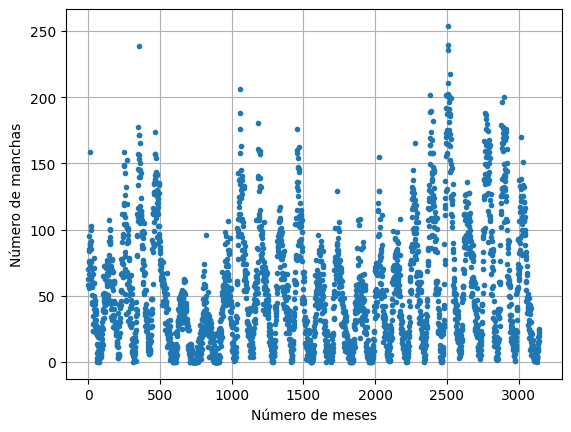

In [11]:
datos = np.loadtxt("manchasolares.txt")    #Abrir el archivo de datos

#Dividimos los datos en dos listas
mes = datos[:,0]
manchas= datos[:,1]

plt.plot(mes, manchas, ".")
plt.grid()
#Ponemos nombres a los ejes
plt.xlabel("Número de meses")
plt.ylabel("Número de manchas")


### 
b) Modifica tu programa para mostrar solo los primeros 1000 datos (experimentales) en la grafica.
#### 

In [12]:
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'Número de manchas')

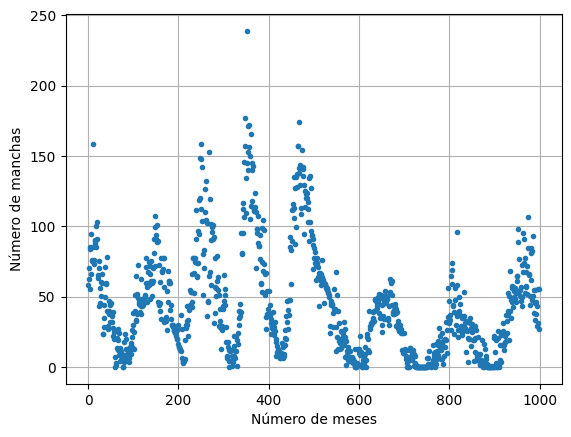

In [23]:
datos = np.loadtxt("manchasolares.txt")    #Abrir el archivo de datos

#Dividimos los datos en dos listas
mes = datos[:,0]
manchas= datos[:,1]

#Tomamos los primeros 1000 elementos de cada lista
x = mes[:1000]
y = manchas[:1000]

plt.plot(x, y, ".")
plt.grid()
#Ponemos nombres a los ejes
plt.xlabel("Número de meses")
plt.ylabel("Número de manchas")

### 
c) Modifica nuevamente tu programa para calcular y graficar la media (promedio) móvil de los datos, definida por:

$$
Y_k = \frac{1}{2r+1} \sum_{-r}^{r}y_{k+m}

$$

donde r = 5 (en este caso) y yk son los numeros de manchas solares. El programa debe graficar tanto los datos originales como la media móvil en el mismo gráfico, sólo sobre los primeros 1000 datos.
#### 

In [24]:
import numpy as np
import matplotlib.pyplot as plt

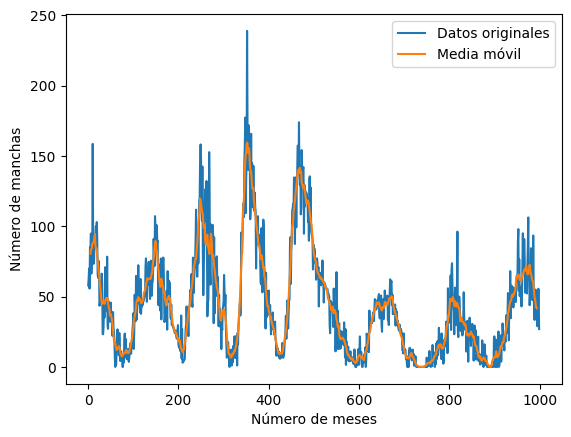

In [68]:
datos = np.loadtxt("manchasolares.txt")    #Abrir el archivo de datos

#Dividimos los datos en dos listas
mes = datos[:,0]
manchas= datos[:,1]

#Tomamos los primeros 1000 elementos de cada lista
y = mes[:1000]
x = manchas[:1000]

mediamovil =[] #Lista vacía para guardar las medias
mes_media =[]
#Calculamos la media movil
for k in range(5, 995): #Inicia en 5 ya que al hacer k+m, sólo en k=5 tenemos el primer elemento de la suma
    suma = 0

    for m in range (-5, 6):

        suma = suma + x[k+m]

        media=suma / (2*5 +1)

    #Agregamos el promedio.
    mediamovil.append(media)
    mes_media.append (y[k])

#Grafica de los primeros 1000 datos
plt.plot(y, x, label="Datos originales")

#Grafica de las medias móviles de los primeros 1000 datos
plt.plot(mes_media, mediamovil, label="Media móvil")

#Ponemos nombres a los ejes
plt.xlabel("Número de meses")
plt.ylabel("Número de manchas")

plt.legend()



### **2.  La gráfica de Feigenbaum (caos determinista)** 

En un especial halloween de los Simpsons, Homero viaja al pasado a la era Jurásica y
por un pequeño descuido cambia el curso de toda la historia en el futuro. Lo anterior
es una referencia al cuento *A Sound of Thunder* de 1952 del escritor de ciencia ficción
Ray Bradbury en donde lo que se destruye en el pasado es una mariposa. Esta idea
fue retomada y popularizada por el físico Edward Lorenz en 1972 cuando dio una
conferencia en la Asociación Estadounidense para el Avance de la Ciencia (*American
Association for the Advancement of Science*) titulada "¿El aleteo de una mariposa en Brasil
puede provocar un tornado en Texas?". Dando paso al concepto del **efecto mariposa**, del
cual probablemente hayas oído hablar y que es el ejemplo clásico de **caos determinista**
en sistemas climáticos. El caos determinista también aparece en muchos sistemas
físicos más complejos, incluyendo especialmente la dinámica de fluidos. Debido a su naturaleza aparentemente aleatoria, el comportamiento de los sistemas caóticos
es difícil de predecir y se ve fuertemente afectado por pequeñas perturbaciones en
las condiciones iniciales. Uno de los ejemplos más famosos del fenómeno del caos
determinista es sin duda el **mapeo logístico**, que es un sistema matemático muy simple,
definido por la ecuación:

$$x_{n+1} = r x_n (1 - x_n)$$

Para un valor dado de la constante $r$, se toma un valor de $x_n$ (digamos $x = \frac{1}{2}$) y se
introduce en el lado derecho de esta ecuación y regresa un valor de $x_{n+1}$. Luego se
toma ese valor y se vuelve a introducir en el lado derecho, lo que da otro valor, y así
sucesivamente. Esto es un mapeo iterativo. Se continúa haciendo la misma operación
una y otra vez sobre su valor de $x_n$, y entonces sucede una de las tres siguientes situaciones:

1. El valor se establece en un número fijo y permanece allí. Esto se llama **punto fijo**.
   Por ejemplo, $x_n = 0$ es siempre un punto fijo del mapeo logístico. (Si se pone
   $x_n = 0$ en el lado derecho se obtiene $x_{n+1} = 0$ en el lado izquierdo).

2. No se establece en un solo valor, sino que se establece en un patrón periódico,
   rotando alrededor de un conjunto de valores, digamos cuatro valores, repitiéndose
   en secuencia una y otra vez. Esto se llama **órbita** (en este caso de periodo 4) o **ciclo
   límite**.

3. Todo enloquece. El mapeo genera una secuencia aparentemente aleatoria de
   números que parecen no tener ni patrón ni razón (ni ton ni son). Esto es el **caos
   determinista**. "Caos" porque realmente parece caótico y "determinista" porque
   aunque los valores parecen aleatorios, no lo son. Son a todas luces, totalmente
   predecibles, porque se obtienen mediante una simple ecuación y el comportamiento
   está determinado, aunque no lo parezca.

## Responde a las siguientes preguntas:

**(a)** Apóyate en el programa que vimos en clase y escribe un programa que muestre
el comportamiento del mapeo logístico mediante una gráfica.

> **Hint:** Esto es lo que debes hacer para hacer tu programa:
>
> Para un valor dado de $r$, comienza con $x_n = \frac{1}{2}$ e itera la ecuación del mapeo
> logístico mil veces. Eso le dará la oportunidad de establecerse en un punto fijo o
> en una órbita de algún periodo. Luego ejecuta otras mil iteraciones y grafica los
> puntos $(r, x_\infty)$ en una gráfica donde el eje horizontal es $r$ y el eje vertical es $x_\infty$.
> Puedes usar la función `plot` con las opciones `"ko"` o `"k."` para dibujar una gráfica
> con puntos, uno para cada punto, o puedes usar la función `scatter` para dibujar
> un diagrama de dispersión (que siempre usa puntos). Repite todo el cálculo para
> valores de $r$ de 1 a 4 en pasos de 0.01, graficando los puntos para todos los valores de $r$ en la misma figura. Tu programa debería generar la distintiva gráfica que
> parece un árbol inclinado hacia un lado. Esta famosa imagen se llama **Gráfica de
> Feigenbaum**, en honor a su descubridor Mitchell Feigenbaum.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

C:\Users\franq\AppData\Local\Temp\ipykernel_21072\2385662906.py:14: RuntimeWarning: overflow encountered in scalar multiply
  x = r* x * (1-x)


Text(0, 0.5, 'x')

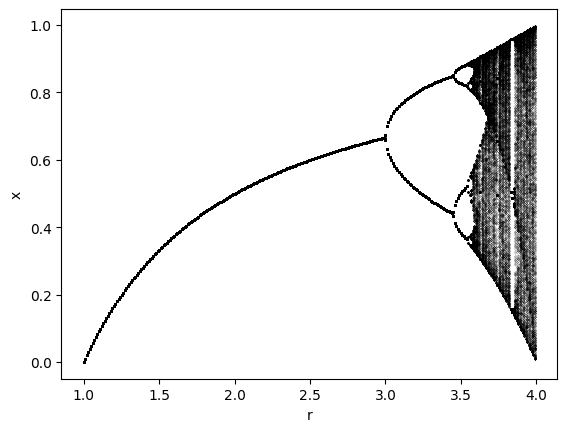

In [13]:
#Creamos dos listas vacías para ir guardando los datos.

r_graf= []
x_graf = []

#Hacemos los valores de r
for r in np.arange(1, 4.01, 0.01):

    #Inicia en 0.5
    x=0.5

#Hacer la operación mil veces una vez para que se establezca en un punto fijo.
    for i in range(1000):
        x = r* x * (1-x)

#Otras mil veces una vez para graficarlas.
    for i in range(1000):
        x = r* x*(1-x)
        x_graf.append(x)
        r_graf.append(r)

plt.plot(r_graf,x_graf, "k.", markersize=0.2)
#Ponemos nombre a los ejes
plt.xlabel("r")
plt.ylabel("x")

**(b)** De acuerdo a tu gráfica, ¿a qué valor de $r$ el sistema pasa de un comportamiento
ordenado (puntos fijos o ciclos límite) a un comportamiento caótico? A este punto
a veces se le llama “el borde del caos”.


 *De acuerdo con la gráfica, es posible notar que cerca de $r=3$, el comportamiento aún está bonito, no es caótico, pero un poco antes de $r=3.5$ empieza el caos, las ramas empiezan a crecer de forma "descontrolada"*




**(c) \*\* Opcional (para 1.5 puntos extra):** Hay otra forma para calcular el diagrama
de Feigenbaum, que puede ser más claro y rápido, dado que hace uso de la
capacidad de Python para realizar aritmética con arreglos completos. Crear un
arreglo r que contenga cada valor distinto de $r$, [1.0, 1.01, 1.02, ...]. Crea
otro arreglo x del mismo tamaño para guardar los valores correspondientes de
$x$, establecidos inicialmente en 0.5; finalmente realiza una iteración del mapeo
logístico para todos los valores de $r$ a la vez, con una sola instrucción de la forma
x = r*x*(1-x) y compárala con tu programa anterior.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

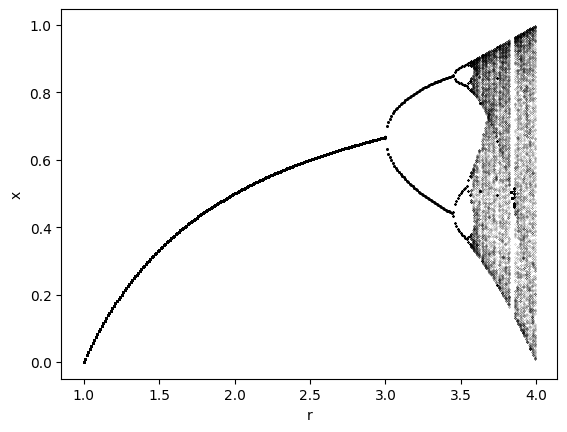

In [9]:

#Tomamos el arreglo de r
r = np.arange(1.0, 4.0, 0.01)
#x debe tener el mismo tamaño que r, lo hacemos de unos
x = np.ones(len(r))*0.5

for i in r:
    x = r*x* (1-x)

 #Hacer la operación mil veces una vez para que se establezca en un punto fijo.
    for i in range(1000):
        x = r* x * (1-x)

#Otras mil veces una vez para graficarlas.
    for i in range(1000):
        x = r* x*(1-x)


    plt.plot(r,x, "k.",markersize=0.2)
    #Ponemos nombre a los ejes
    plt.xlabel("r")
    plt.ylabel("x")

### **3. El conjunto de Mandelbrot** 


In [2]:
import numpy as np
import matplotlib.pyplot as plt

C:\Users\franq\AppData\Local\Temp\ipykernel_21072\1854033222.py:15: RuntimeWarning: overflow encountered in square
  z = z**2 + c
C:\Users\franq\AppData\Local\Temp\ipykernel_21072\1854033222.py:15: RuntimeWarning: invalid value encountered in square
  z = z**2 + c


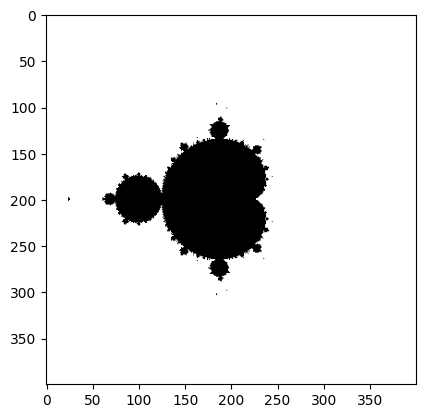

In [20]:
#Creamos dos ejes, x e y
x = np.linspace(-2,2,400)
y = np.linspace(-2,2,400)
#Esto crea un plano
X,Y = np.meshgrid(x,y)

#Lo que vamos a variar es c
c =X+ 1j*Y
z = 0 + 1j*0

#Matriz de ceros para guardar los resultados
c_mandel = np.zeros ((400,400))

for i in range(100):
    z = z**2 + c
#Un par de ciclos for para hacerlo las veces que necesitamos
for i in range(len(z)):
    for k in range(len(z)):
        
        if np.abs(z[i][k])<2:  #Queremos que se cumpla la condición de que |z| <2
            c_mandel[i][k] = 1

plt.imshow(c_mandel, cmap="gray_r")

plt.show()